In [ ]:
"""
Optimization of Boring Bar Dynamics
5-section rotating bar, FEM + modal reduction
Multi-objective: maximise alim, maximise static stiffness, minimise mass
Single design parameter: cavity start from free end (z_from_tip)
"""

import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':9,'axes.titlesize':9.5,'axes.labelsize':9,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':7.5,'figure.dpi':150})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1.  PARAMETERS
# ══════════════════════════════════════════════════════════════
E_body   = 280e9
rho_body = 7850.0 * 1.2    # kg/m³
rho_tc   = 15600.0         # tungsten carbide absorber

L_total  = 0.300           # m
D1_out   = 0.060           # Sec1 outer diameter
R_in    = 0.030            # Sec1 inner radius
D_main   = 0.040           # Sec2-5 outer diameter
d_wall   = 0.003           # cavity wall thickness (≥3 mm, Sec4 only)

L1 = 0.050   # large cylinder (fixed end)
L2 = 0.040   # taper
L4 = 0.060   # cavity length (fixed)
L5_min = 0.030             # minimum solid tip

# Cavity start measured from FREE end → z_cav = L_total - L5 - L4
# z_from_tip ∈ [L5_min, L_total - L4 - (L1+L2) - 5mm]
ztip_min = L5_min                              # 30 mm
ztip_max = L_total - L4 - (L1+L2) - 0.005    # 125 mm

# ── Cutting (boring, single-point) ────────────────────────────
Nt=1; Ktc=2000e6; Krc=800e6; ratio_kr=Krc/Ktc
zeta_s = 0.01

N_ELEM  = 60
N_MODES = 6

def ztip_to_zcav(ztip):
    """Convert 'distance from free end' → axial z from fixed end."""
    return L_total - ztip - L4

print(f"Bar: L={L_total*1e3:.0f}mm  D1={D1_out*1e3:.0f}mm  Dmain={D_main*1e3:.0f}mm")
print(f"Cavity (L4={L4*1e3:.0f}mm) start from tip: {ztip_min*1e3:.0f}–{ztip_max*1e3:.0f} mm")

Bar: L=300mm  D1=60mm  Dmain=40mm
Cavity (L4=60mm) start from tip: 30–145 mm


In [ ]:
# ══════════════════════════════════════════════════════════════
# 2.  CROSS-SECTION  (corrected geometry)
#     Sec1,2,3,5 → SOLID.  Sec4 → HOLLOW (wall = d_wall)
# ══════════════════════════════════════════════════════════════
def xsec(z, z_cav):
    z2 = L1+L2; z3 = z_cav; z4 = z_cav+L4
    if   z < L1: Ro = D1_out/2;Ri=R_in
    elif z < z2: Ro = D1_out/2 + (z-L1)/L2*(D_main-D1_out)/2;Ri=R_in
    elif z < z3: Ro = D_main/2;Ri=R_in
    else:        Ro = D_main/2
    Ri = (Ro - d_wall) if (z3 <= z < z4) else 0.0
    A  = np.pi*(Ro**2 - Ri**2)
    I  = np.pi*(Ro**4 - Ri**4)/4
    Ip = np.pi*(Ro**4 - Ri**4)/2
    return A, I, Ip, rho_body*A, rho_body*I, rho_body*Ip

In [ ]:
# ══════════════════════════════════════════════════════════════
# 3.  FEM  (Hermite cubic, 3-pt Gauss, clamped at z=0)
# ══════════════════════════════════════════════════════════════
gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
gw = np.array([5/9, 8/9, 5/9])

def build_MK(z_cav):
    ne=N_ELEM; nn=ne+1; le=L_total/ne
    zn=np.linspace(0,L_total,nn); dof=2*nn
    Mg=np.zeros((dof,dof)); Kg=np.zeros((dof,dof)); Gg=np.zeros((dof,dof))
    for e in range(ne):
        za=zn[e]
        Ke=np.zeros((4,4)); Me=np.zeros((4,4)); Ge=np.zeros((4,4))
        for g,w in zip(gp,gw):
            xi=(g+1)/2; zg=za+xi*le
            _,Ig,Ipg,rhoAg,rhoIg,rhoIpg = xsec(zg,z_cav)
            N1=1-3*xi**2+2*xi**3;  N2=le*(xi-2*xi**2+xi**3)
            N3=3*xi**2-2*xi**3;    N4=le*(-xi**2+xi**3)
            dN1=(-6*xi+6*xi**2)/le;  dN2=1-4*xi+3*xi**2
            dN3=(6*xi-6*xi**2)/le;   dN4=-2*xi+3*xi**2
            d2N1=(-6+12*xi)/le**2;   d2N2=(-4+6*xi)/le
            d2N3=(6-12*xi)/le**2;    d2N4=(-2+6*xi)/le
            Nv=np.array([N1,N2,N3,N4]); dN=np.array([dN1,dN2,dN3,dN4])
            d2N=np.array([d2N1,d2N2,d2N3,d2N4]); fac=le*w/2
            Ke += E_body*Ig*np.outer(d2N,d2N)*fac
            Me += (rhoAg*np.outer(Nv,Nv)+rhoIg*np.outer(dN,dN))*fac
            Ge += rhoIpg*np.outer(dN,dN)*fac
        idx=[2*e,2*e+1,2*(e+1),2*(e+1)+1]
        for i,ii in enumerate(idx):
            for j,jj in enumerate(idx):
                Mg[ii,jj]+=Me[i,j]; Kg[ii,jj]+=Ke[i,j]; Gg[ii,jj]+=Ge[i,j]
    free=list(range(2,dof))
    sl=np.ix_(free,free)
    return Mg[sl],Kg[sl],Gg[sl],Mg[sl]   # Mf,Kf,Gf,Mcf

In [ ]:
# ══════════════════════════════════════════════════════════════
# 4.  MODAL REDUCTION
# ══════════════════════════════════════════════════════════════
def modal_reduce(z_cav):
    Mf,Kf,Gf,Mcf = build_MK(z_cav)
    evals,evecs = eigh(Kf,Mf,subset_by_index=[0,N_MODES-1])
    wn = np.sqrt(np.maximum(evals,0))
    scale = np.sqrt(np.diag(evecs.T@Mf@evecs))
    Phi = evecs/scale                          # mass-normalised
    Gm  = Phi.T@Gf@Phi
    Mcm = Phi.T@Mcf@Phi
    tip = Phi[2*(N_ELEM-1),:]                  # tip translational DOF
    Cm  = 2*zeta_s*wn
    return dict(wn=wn,Phi=Phi,Gm=Gm,Mcm=Mcm,tip=tip,Cm=Cm,
                Mf=Mf,Kf=Kf)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5.  ABSORBER GEOMETRY
# ══════════════════════════════════════════════════════════════
def absorber_params(z_cav):
    R_cav = D_main/2 - d_wall
    md = rho_tc * 0.70 * np.pi*R_cav**2*L4   # 70% fill
    z_d = z_cav + L4/2
    return md, z_d

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.  MODAL FRF  (2-plane + absorber)
# ══════════════════════════════════════════════════════════════
def frf(modal, freqs_hz, Omega, z_cav, kd=0.0, cd=0.0):
    N   = N_MODES
    wn  = modal['wn']; tip = modal['tip']
    Gm  = modal['Gm']; Cm_d= modal['Cm']
    Km_eff = np.diag(wn**2) - Omega**2*modal['Mcm']

    md, z_d = absorber_params(z_cav)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]          # mode shapes at absorber location

    n2=2*N
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)

    use_absorber = (kd > 0)
    na = n2+2 if use_absorber else n2

    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f; w2=w**2
        Z=np.zeros((na,na),dtype=complex)
        # diagonal modal blocks (x-plane: rows 0..N-1, y-plane: rows N..2N-1)
        for r in range(N):
            d = -w2 + 1j*w*Cm_d[r] + Km_eff[r,r]
            Z[r,r]=d; Z[N+r,N+r]=d
        # gyroscopic off-diagonal
        Z[:N,N:n2] +=  2j*w*Omega*Gm
        Z[N:n2,:N] += -2j*w*Omega*Gm
        if use_absorber:
            # absorber-beam coupling (x-plane)
            for r in range(N):
                coup = (kd+1j*w*cd)*Phi_d[r]
                Z[r,r]    += Phi_d[r]*coup
                Z[r,n2]   -= coup
                Z[n2,r]   -= coup
            Z[n2,n2] = -w2*md + kd - Omega**2*md + 1j*w*cd
            # absorber-beam coupling (y-plane)
            for r in range(N):
                coup = (kd+1j*w*cd)*Phi_d[r]
                Z[N+r,N+r]+= Phi_d[r]*coup
                Z[N+r,n2+1]-= coup
                Z[n2+1,N+r]-= coup
            Z[n2+1,n2+1] = -w2*md + kd - Omega**2*md + 1j*w*cd
            # absorber Coriolis
            Z[n2,n2+1]= 2j*w*Omega*md
            Z[n2+1,n2]=-2j*w*Omega*md
        # Force at tip, x-direction
        fx=np.zeros(na,dtype=complex); fx[:N]=tip
        fy=np.zeros(na,dtype=complex); fy[N:n2]=tip
        try:
            sol=np.linalg.solve(Z,np.column_stack([fx,fy]))
            Hxx[k]=tip@sol[:N,0]; Hxy[k]=tip@sol[:N,1]
        except: pass
    return Hxx,Hxy

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.  DIRECTIONAL COEFFICIENTS  (boring, 360° cut)
# ══════════════════════════════════════════════════════════════
phi=np.linspace(0,2*np.pi,100000)
axx_b=np.trapezoid(np.sin(phi)*(-np.cos(phi)-ratio_kr*np.sin(phi)),phi)/(2*np.pi)
axy_b=np.trapezoid(np.cos(phi)*(-np.cos(phi)-ratio_kr*np.sin(phi)),phi)/(2*np.pi)
ayx_b=np.trapezoid(np.sin(phi)*( np.sin(phi)-ratio_kr*np.cos(phi)),phi)/(2*np.pi)
ayy_b=np.trapezoid(np.cos(phi)*( np.sin(phi)-ratio_kr*np.cos(phi)),phi)/(2*np.pi)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8.  STABILITY LIMIT  (Budak-Altintas eigenvalue)
# ══════════════════════════════════════════════════════════════
def alim_from_FRF(Hxx, Hxy):
    best = np.inf
    for k in range(len(Hxx)):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        disc=tr**2-4*det; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*det),(-tr-sq)/(2*det)]:
            rl=np.real(lam)
            if rl<0:
                kap=np.imag(lam)/(rl+1e-30)
                al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
                if 0<al<best: best=al
    return min(best,0.025) if best<np.inf else 0.0

In [ ]:
# ══════════════════════════════════════════════════════════════
# 9.  ABSORBER TUNING  (Den Hartog → 1-D refinement each axis)
# ══════════════════════════════════════════════════════════════
def tune_absorber(z_cav, modal, n_speeds=7):
    md,_ = absorber_params(z_cav)
    wn1  = modal['wn'][0]
    # Den Hartog starting point
    mu   = max(md/(rho_body*np.pi*(D_main/2)**2*L_total), 0.01)
    wd   = wn1/(1+mu)
    kd0  = md*wd**2
    cd0  = 2*np.sqrt(3*mu/(8*(1+mu)**3))*md*wd
    freqs_s = np.linspace(10,800,200)
    Oms     = np.linspace(0,6000,n_speeds)*2*np.pi/60

    def score(lkd, lcd):
        kd_=10**lkd; cd_=10**lcd
        tot=0
        for Om in Oms:
            H,Hxy_=frf(modal,freqs_s,Om,z_cav,kd_,cd_)
            Hb,Hxyb=frf(modal,freqs_s,Om,z_cav,0,0)
            a=alim_from_FRF(H,Hxy_); ab=alim_from_FRF(Hb,Hxyb)
            tot+=max(min(a,ab*50),ab)
        return -tot

    r1=minimize_scalar(lambda lk:score(lk,np.log10(cd0+1)),
                       bounds=(np.log10(kd0)-1.5,np.log10(kd0)+1.5),
                       method='bounded',options={'xatol':0.12,'maxiter':18})
    kd_opt=10**r1.x
    r2=minimize_scalar(lambda lc:score(np.log10(kd_opt),lc),
                       bounds=(0,np.log10(6*cd0+1)),
                       method='bounded',options={'xatol':0.12,'maxiter':18})
    cd_opt=10**r2.x
    return kd_opt, cd_opt, md

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10.  BAR MASS
# ══════════════════════════════════════════════════════════════
def bar_mass(z_cav):
    """Total system mass = bar body (with cavity removed) + TC absorber."""
    zz=np.linspace(0,L_total,2001); dz=L_total/2000
    m_bar = sum(rho_body*xsec(z,z_cav)[0]*dz for z in (zz[:-1]+zz[1:])/2)
    md, _ = absorber_params(z_cav)
    return m_bar + md

In [ ]:
# ══════════════════════════════════════════════════════════════
# 11.  SWEEP  (parameter: distance from free end)
# ══════════════════════════════════════════════════════════════
N_PTS = 16
ztip_arr = np.linspace(ztip_min, ztip_max, N_PTS)
freqs_frf  = np.linspace(5,800,350)
freqs_stab = np.linspace(10,800,250)
Oms_eval   = np.linspace(0,6000,9)*2*np.pi/60

results=[]
print(f"\nSweeping {N_PTS} cavity positions (from tip)…")
for i,ztip in enumerate(ztip_arr):
    z_cav = ztip_to_zcav(ztip)
    print(f"  [{i+1:2d}/{N_PTS}] ztip={ztip*1e3:.1f}mm (z_cav={z_cav*1e3:.1f}mm)",end=' ',flush=True)
    modal = modal_reduce(z_cav)
    kd,cd,md = tune_absorber(z_cav,modal)

    # Obj-1: mean stability limit [mm]
    alims=[]
    for Om in Oms_eval:
        Ha,Hxa = frf(modal,freqs_stab,Om,z_cav,kd,cd)
        Hb,Hxb = frf(modal,freqs_stab,Om,z_cav,0,0)
        a=alim_from_FRF(Ha,Hxa)*1e3; b=alim_from_FRF(Hb,Hxb)*1e3
        alims.append(max(min(a,b*50),b))
    alim_mean = np.mean(alims)

    # Obj-2: static tip stiffness [N/m] — direct FEM solve (exact)
    Mf_,Kf_,_,_ = build_MK(z_cav)
    tip_dof = 2*(N_ELEM-1)
    f_static = np.zeros(Kf_.shape[0]); f_static[tip_dof]=1.0
    u_static = np.linalg.solve(Kf_, f_static)
    static_stiff = 1.0 / u_static[tip_dof]       # N/m

    # Obj-3: first natural frequency fn1 [Hz]  (maximise → stiffer/lighter)
    fn1  = modal['wn'][0]/(2*np.pi)

    # Also track mass for info
    mass = bar_mass(z_cav)

    print(f"alim={alim_mean:.2f}mm K={static_stiff/1e6:.3f}MN/m fn1={fn1:.0f}Hz m={mass*1e3:.0f}g")
    results.append(dict(ztip=ztip,z_cav=z_cav,kd=kd,cd=cd,md=md,
                        modal=modal,alim=alim_mean,stiff=static_stiff,
                        fn1=fn1,mass=mass))


Sweeping 16 cavity positions (from tip)…
  [ 1/16] ztip=30.0mm (z_cav=210.0mm) alim=22.68mm K=6.979MN/m fn1=608Hz m=4649g
  [ 2/16] ztip=37.7mm (z_cav=202.3mm) alim=19.44mm K=6.883MN/m fn1=588Hz m=4649g
  [ 3/16] ztip=45.3mm (z_cav=194.7mm) alim=17.47mm K=6.800MN/m fn1=574Hz m=4649g
  [ 4/16] ztip=53.0mm (z_cav=187.0mm) alim=14.64mm K=6.689MN/m fn1=557Hz m=4649g
  [ 5/16] ztip=60.7mm (z_cav=179.3mm) alim=13.23mm K=6.579MN/m fn1=543Hz m=4649g
  [ 6/16] ztip=68.3mm (z_cav=171.7mm) alim=10.89mm K=6.470MN/m fn1=531Hz m=4649g
  [ 7/16] ztip=76.0mm (z_cav=164.0mm) alim=9.72mm K=6.350MN/m fn1=519Hz m=4649g
  [ 8/16] ztip=83.7mm (z_cav=156.3mm) alim=7.98mm K=6.233MN/m fn1=509Hz m=4649g
  [ 9/16] ztip=91.3mm (z_cav=148.7mm) alim=6.89mm K=6.106MN/m fn1=498Hz m=4649g
  [10/16] ztip=99.0mm (z_cav=141.0mm) alim=5.52mm K=5.982MN/m fn1=488Hz m=4649g
  [11/16] ztip=106.7mm (z_cav=133.3mm) alim=4.88mm K=5.850MN/m fn1=478Hz m=4649g
  [12/16] ztip=114.3mm (z_cav=125.7mm) alim=3.87mm K=5.724MN/m fn1=469H

In [ ]:
# ══════════════════════════════════════════════════════════════
# 12.  PARETO  +  WEIGHTED-SUM OPTIMUM
# ══════════════════════════════════════════════════════════════
ztip_v = np.array([r['ztip']  for r in results])*1e3   # mm from tip
z_cav_v= np.array([r['z_cav'] for r in results])*1e3   # mm from fixed end
alim_v = np.array([r['alim']  for r in results])
stiff_v= np.array([r['stiff'] for r in results])/1e6
fn1_v  = np.array([r['fn1']   for r in results])
mass_v = np.array([r['mass']  for r in results])

def n01(x): return (x-x.min())/(x.max()-x.min()+1e-30)
# Three objectives — all maximise:
f1 = n01(alim_v)    # stability    → maximise
f2 = n01(stiff_v)   # stiffness    → maximise
f3 = n01(fn1_v)     # nat. freq    → maximise

# Pareto front
def is_dominated(i):
    for j in range(len(results)):
        if j==i: continue
        if f1[j]>=f1[i] and f2[j]>=f2[i] and f3[j]>=f3[i] and \
           (f1[j]>f1[i]  or  f2[j]>f2[i]  or  f3[j]>f3[i]):
            return True
    return False
pareto_mask = np.array([not is_dominated(i) for i in range(len(results))])

score   = (f1+f2+f3)/3
i_best  = np.argmax(score)
i_alim  = np.argmax(alim_v)
i_stiff = np.argmax(stiff_v)
i_fn1   = np.argmax(fn1_v)
best    = results[i_best]

print("\n"+"="*60)
print("MULTI-OBJECTIVE RESULTS  (3 objectives)")
print("="*60)
print(f"  {'Objective':<25} {'Best z_tip':>10} {'Value':>12}")
print(f"  {'-'*25} {'-'*10} {'-'*12}")
print(f"  {'Max stability (alim)':<25} {ztip_v[i_alim]:>9.1f}mm {alim_v[i_alim]:>10.3f} mm")
print(f"  {'Max static stiffness':<25} {ztip_v[i_stiff]:>9.1f}mm {stiff_v[i_stiff]:>10.3f} MN/m")
print(f"  {'Max nat. freq fn1':<25} {ztip_v[i_fn1]:>9.1f}mm {fn1_v[i_fn1]:>10.1f} Hz")
print(f"\n★ Best balanced (equal weights): z_tip = {ztip_v[i_best]:.1f} mm"
      f"  (z_cav = {z_cav_v[i_best]:.1f} mm from fixed end)")
print(f"   alim={best['alim']:.3f}mm  K={best['stiff']/1e6:.3f}MN/m  fn1={best['fn1']:.0f}Hz")
print(f"   kd={best['kd']:.3e}N/m  cd={best['cd']:.1f}Ns/m  md={best['md']*1e3:.0f}g")
print(f"  Pareto front: {pareto_mask.sum()} / {len(results)} points")
print("="*60)


MULTI-OBJECTIVE RESULTS  (3 objectives)
  Objective                 Best z_tip        Value
  ------------------------- ---------- ------------
  Max stability (alim)           30.0mm     22.681 mm
  Max static stiffness           30.0mm      6.979 MN/m
  Max nat. freq fn1              30.0mm      607.8 Hz

★ Best balanced (equal weights): z_tip = 30.0 mm  (z_cav = 210.0 mm from fixed end)
   alim=22.681mm  K=6.979MN/m  fn1=608Hz
   kd=4.566e+06N/m  cd=1118.2Ns/m  md=595g
  Pareto front: 1 / 16 points


In [ ]:
# ══════════════════════════════════════════════════════════════
# 13.  STABILITY LOBE DIAGRAM  (Budak-Altintas lobes)
# ══════════════════════════════════════════════════════════════
def stability_lobes(modal, z_cav, kd, cd, n_chatter=400, rpm_max=6000):
    """Returns spindle_speed [RPM] and alim [mm] arrays for lobe diagram."""
    freqs_c  = np.linspace(10, 800, n_chatter)
    speeds   = []; depths = []
    Omega_dummy = 0.0   # lobes computed at zero speed (standard approach)
    Hxx,Hxy = frf(modal,freqs_c,Omega_dummy,z_cav,kd,cd)
    for k,fc in enumerate(freqs_c):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        disc=tr**2-4*det; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*det),(-tr-sq)/(2*det)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl>=0: continue
            kap=il/(rl+1e-30)
            al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
            if al<=0 or al>25: continue
            psi = np.arctan2(il,rl)        # phase angle
            # lobe number n=0,1,2,...
            for n in range(0,8):
                eps = np.pi - 2*psi if psi<0 else -(np.pi + 2*psi)
                T   = (eps + 2*np.pi*n)/(2*np.pi*fc)
                if T<=0: continue
                rpm = 60/T
                if 0<rpm<=rpm_max:
                    speeds.append(rpm); depths.append(al*1e3)  # mm
    return np.array(speeds), np.array(depths)

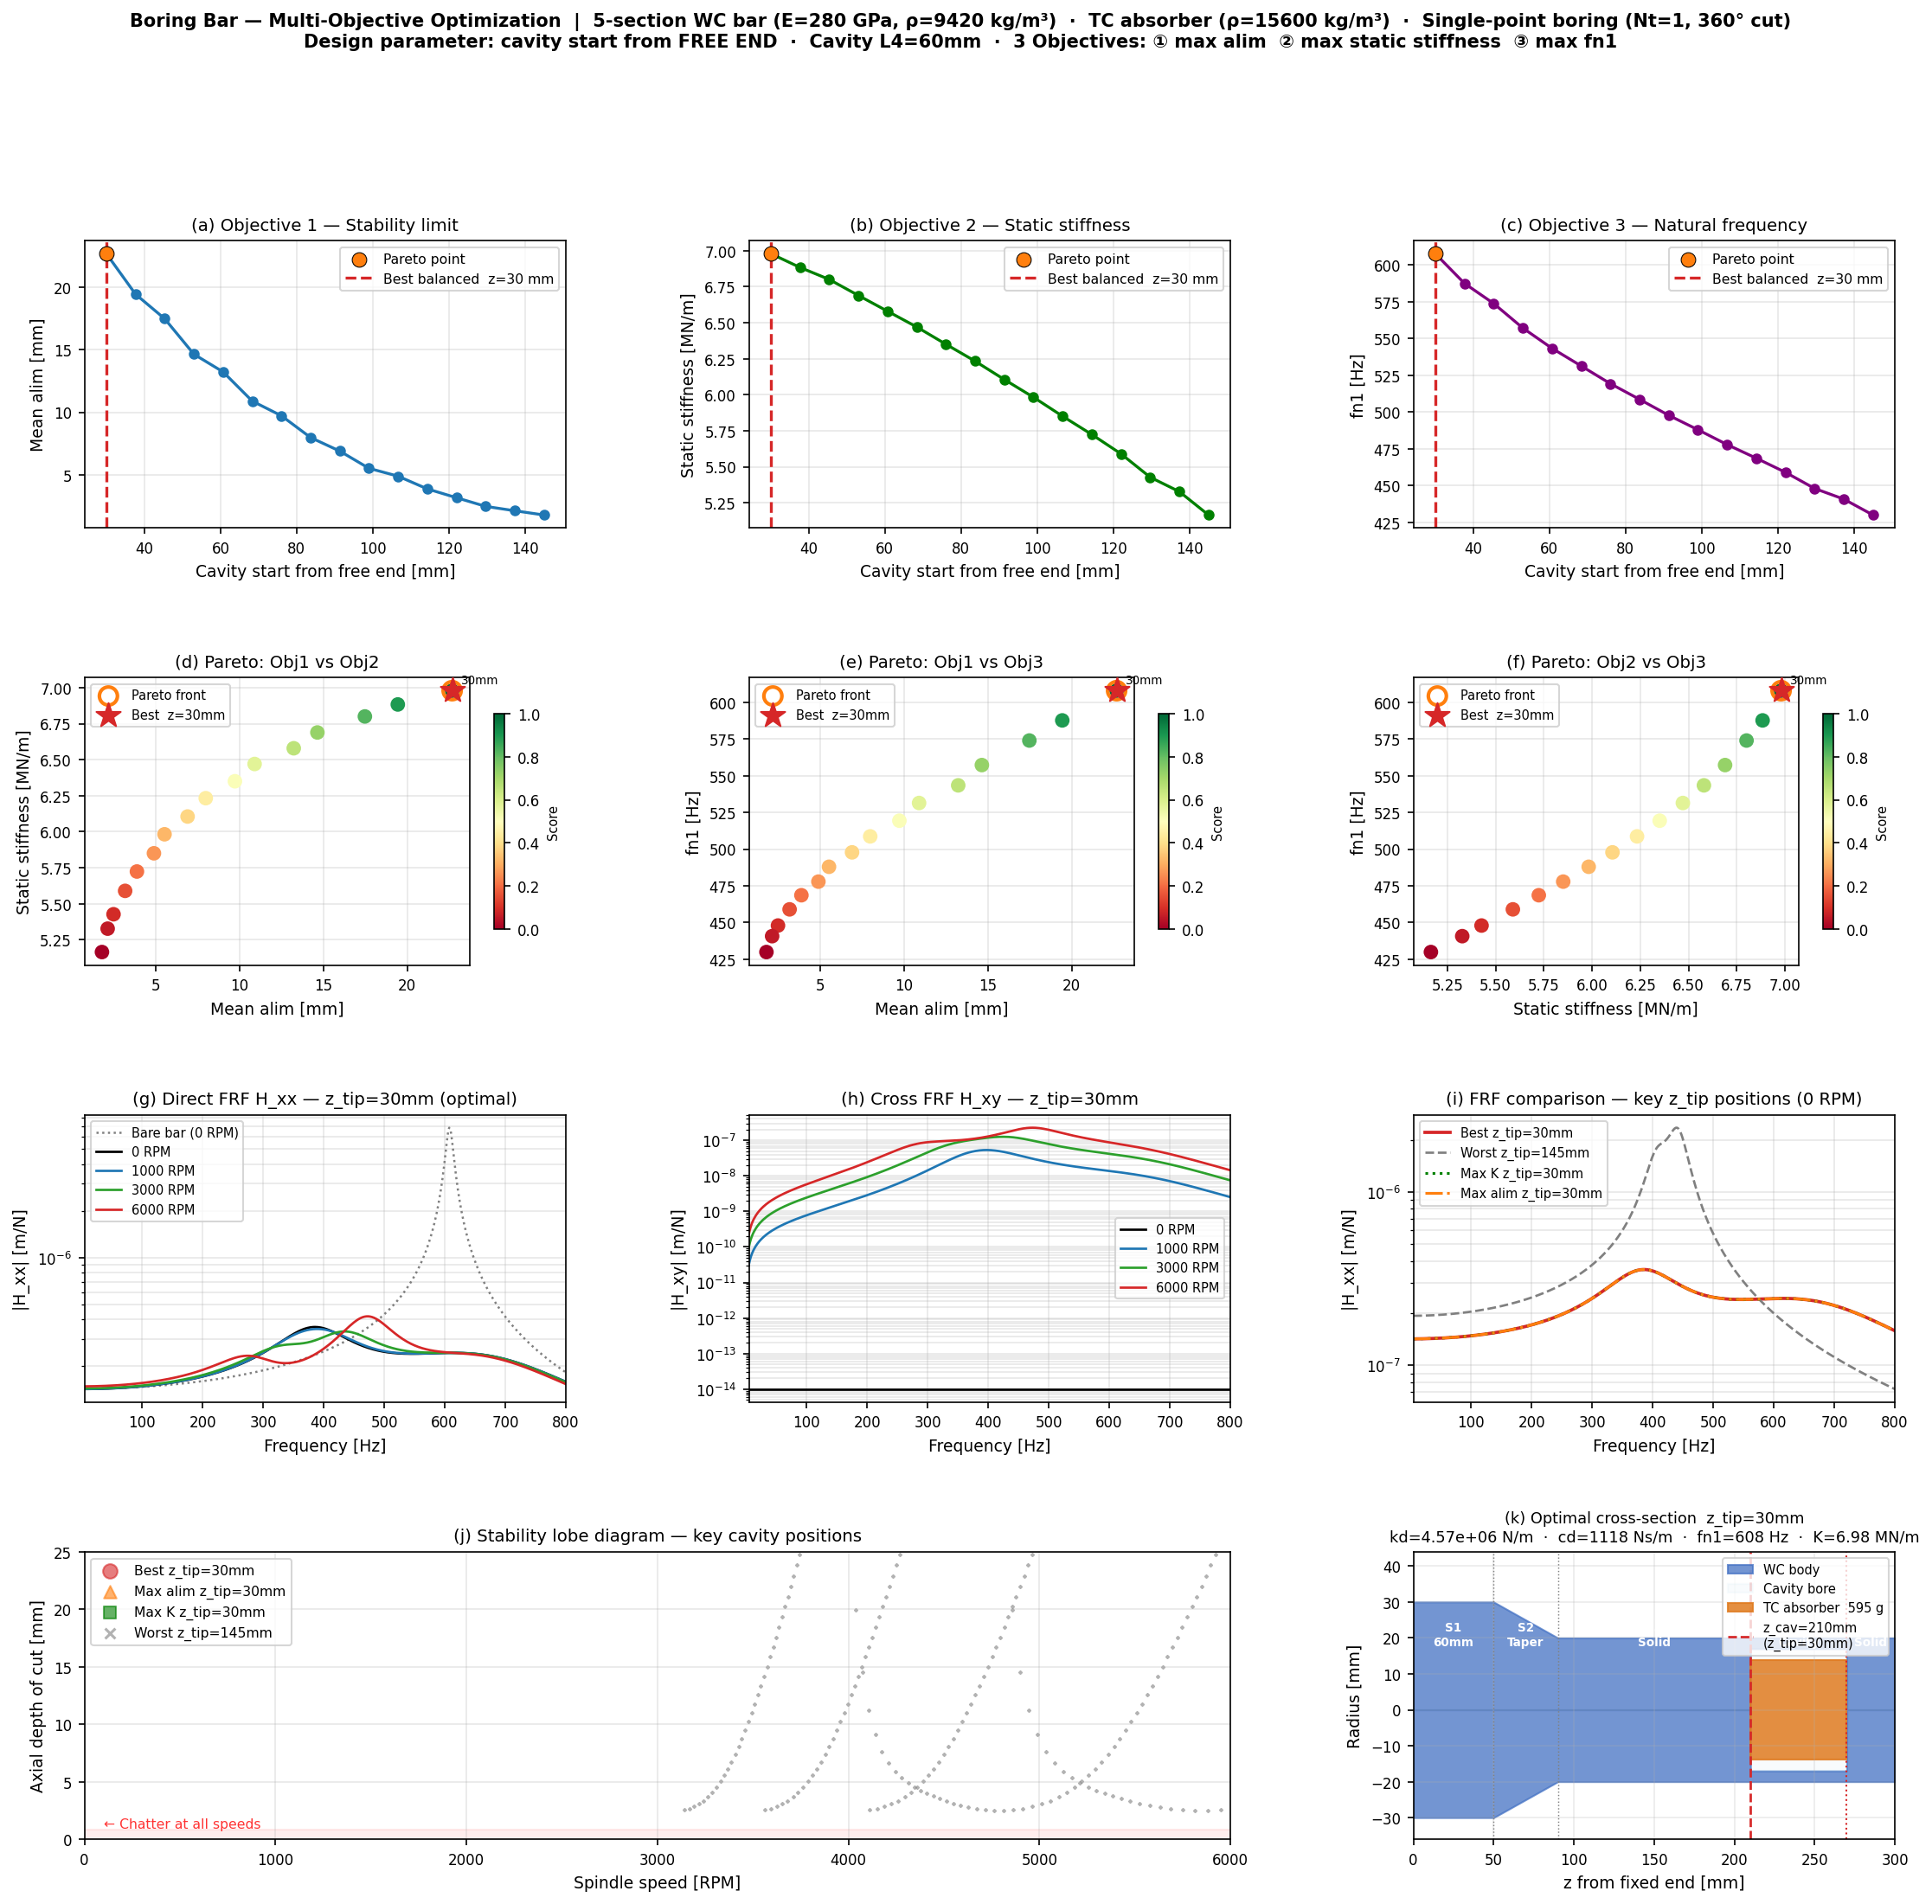


Figure saved → boring_bar_MOO.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# 14.  FIGURE — 4×3 layout
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18,16))
fig.suptitle(
    'Boring Bar — Multi-Objective Optimization  |  '
    f'5-section WC bar (E=280 GPa, ρ=9420 kg/m³)  ·  TC absorber (ρ=15600 kg/m³)  ·  '
    f'Single-point boring (Nt=1, 360° cut)\n'
    f'Design parameter: cavity start from FREE END  ·  '
    f'Cavity L4={L4*1e3:.0f}mm  ·  '
    f'3 Objectives: ① max alim  ② max static stiffness  ③ max fn1',
    fontsize=10, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38)
BEST_C='#D62728'; PARETO_C='#FF7F0E'; NORM_C='#1F77B4'

# ── ROW 0 ── Objective vs cavity position ────────────────────
def obj_panel(ax, ydata, ylabel, title, i_obj, ycolor, pareto_mask, ztip_v, i_best):
    ax.plot(ztip_v, ydata, 'o-', color=ycolor, ms=5, lw=1.6)
    ax.scatter(ztip_v[pareto_mask], ydata[pareto_mask], s=65, color=PARETO_C,
               zorder=4, edgecolors='k', lw=0.5, label='Pareto point')
    ax.axvline(ztip_v[i_best], color=BEST_C, ls='--', lw=1.6,
               label=f'Best balanced  z={ztip_v[i_best]:.0f} mm')
    if i_obj != i_best:
        ax.axvline(ztip_v[i_obj], color=ycolor, ls=':', lw=1.4,
                   label=f'Best this obj  z={ztip_v[i_obj]:.0f} mm')
    ax.set_xlabel('Cavity start from free end [mm]')
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

obj_panel(fig.add_subplot(gs[0,0]), alim_v,  'Mean alim [mm]',
          '(a) Objective 1 — Stability limit',  i_alim,  NORM_C,  pareto_mask, ztip_v, i_best)
obj_panel(fig.add_subplot(gs[0,1]), stiff_v, 'Static stiffness [MN/m]',
          '(b) Objective 2 — Static stiffness', i_stiff, 'green',  pareto_mask, ztip_v, i_best)
obj_panel(fig.add_subplot(gs[0,2]), fn1_v,   'fn1 [Hz]',
          '(c) Objective 3 — Natural frequency', i_fn1,  'purple', pareto_mask, ztip_v, i_best)

# ── ROW 1 ── Pareto 2D projections (colour = combined score) ─
proj_pairs = [
    (alim_v, stiff_v, 'Mean alim [mm]',         'Static stiffness [MN/m]', '(d) Pareto: Obj1 vs Obj2'),
    (alim_v, fn1_v,   'Mean alim [mm]',          'fn1 [Hz]',               '(e) Pareto: Obj1 vs Obj3'),
    (stiff_v,fn1_v,   'Static stiffness [MN/m]', 'fn1 [Hz]',               '(f) Pareto: Obj2 vs Obj3'),
]
for col,(xa,ya,xl,yl,ttl) in enumerate(proj_pairs):
    ax=fig.add_subplot(gs[1,col])
    sc=ax.scatter(xa,ya,c=score,cmap='RdYlGn',s=50,zorder=2,vmin=0,vmax=1)
    ax.scatter(xa[pareto_mask],ya[pareto_mask],s=100,zorder=4,
               edgecolors=PARETO_C,facecolors='none',lw=2,label='Pareto front')
    ax.scatter(xa[i_best],ya[i_best],c=BEST_C,s=200,marker='*',
               zorder=5,label=f'Best  z={ztip_v[i_best]:.0f}mm')
    for idx in np.where(pareto_mask)[0]:
        ax.annotate(f'{ztip_v[idx]:.0f}mm',(xa[idx],ya[idx]),
                    textcoords='offset points',xytext=(5,4),fontsize=6.5)
    cb=plt.colorbar(sc,ax=ax,shrink=0.75); cb.set_label('Score',fontsize=7)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

# ── ROW 2 ── FRF panels ───────────────────────────────────────
speeds_frf=[0,1000,3000,6000]; clrs_frf=['k','#1F77B4','#2CA02C','#D62728']
freqs_frf_plot=np.linspace(5,800,500)
z_b=best['z_cav']; kd_b=best['kd']; cd_b=best['cd']; modal_b=best['modal']
i_worst=np.argmin(score)

# (g) Direct FRF at optimal — bare vs absorber, multiple speeds
ax=fig.add_subplot(gs[2,0])
Hno,_=frf(modal_b,freqs_frf_plot,0,z_b,0,0)
ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hno),1e-14,None),
            color='gray',lw=1.2,ls=':',label='Bare bar (0 RPM)')
for rpm,c in zip(speeds_frf,clrs_frf):
    Hw,_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,z_b,kd_b,cd_b)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                color=c,lw=1.3,label=f'{rpm} RPM')
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
ax.set_title(f'(g) Direct FRF H_xx — z_tip={ztip_v[i_best]:.0f}mm (optimal)')
ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# (h) Cross FRF — gyroscopic coupling grows with speed
ax=fig.add_subplot(gs[2,1])
for rpm,c in zip(speeds_frf,clrs_frf):
    _,Hxy_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,z_b,kd_b,cd_b)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hxy_),1e-14,None),
                color=c,lw=1.3,label=f'{rpm} RPM')
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('|H_xy| [m/N]')
ax.set_title(f'(h) Cross FRF H_xy — z_tip={ztip_v[i_best]:.0f}mm')
ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# (i) FRF comparison across key positions (0 RPM, with absorber)
ax=fig.add_subplot(gs[2,2])
for idx,lbl,c,ls,lw_ in [
    (i_best,  f'Best z_tip={ztip_v[i_best]:.0f}mm',  BEST_C, '-',  1.8),
    (i_worst, f'Worst z_tip={ztip_v[i_worst]:.0f}mm','gray',  '--', 1.3),
    (i_stiff, f'Max K z_tip={ztip_v[i_stiff]:.0f}mm','green', ':',  1.5),
    (i_alim,  f'Max alim z_tip={ztip_v[i_alim]:.0f}mm',PARETO_C,'-.', 1.5)]:
    r=results[idx]
    Hw,_=frf(r['modal'],freqs_frf_plot,0,r['z_cav'],r['kd'],r['cd'])
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                color=c,lw=lw_,ls=ls,label=lbl)
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
ax.set_title('(i) FRF comparison — key z_tip positions (0 RPM)')
ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

# ── ROW 3 ── Stability lobes + cross-section ─────────────────
# (j) Stability lobe diagram
ax=fig.add_subplot(gs[3,0:2])
lobe_cases=[(i_best, f'Best z_tip={ztip_v[i_best]:.0f}mm',  BEST_C,  'o', 4),
            (i_alim, f'Max alim z_tip={ztip_v[i_alim]:.0f}mm', PARETO_C,'^', 3),
            (i_stiff,f'Max K z_tip={ztip_v[i_stiff]:.0f}mm','green', 's', 3),
            (i_worst,f'Worst z_tip={ztip_v[i_worst]:.0f}mm', 'gray',  'x', 2)]
for idx,lbl,c,mk,ms_ in lobe_cases:
    r=results[idx]
    sp,dp=stability_lobes(r['modal'],r['z_cav'],r['kd'],r['cd'])
    if len(sp):
        ax.scatter(sp,dp,s=ms_,c=c,marker=mk,alpha=0.6,label=lbl)
ax.set_xlim(0,6000); ax.set_ylim(0,25)
ax.set_xlabel('Spindle speed [RPM]'); ax.set_ylabel('Axial depth of cut [mm]')
ax.set_title('(j) Stability lobe diagram — key cavity positions')
ax.legend(markerscale=4,fontsize=7.5); ax.grid(True,alpha=0.3)
ax.axhspan(0,0.8,alpha=0.07,color='red')
ax.text(100,1.0,'← Chatter at all speeds',fontsize=7.5,color='red',alpha=0.8)

# (k) Cross-section at optimal position
ax=fig.add_subplot(gs[3,2])
zz=np.linspace(0,L_total,3000); z2_=L1+L2; z3_=z_b; z4_=z_b+L4
Ro_p=[]; Ri_p=[]
for zp in zz:
    if zp<L1: Ro=D1_out/2;Ri=R_in
    elif zp<z2_: Ro=D1_out/2+(zp-L1)/L2*(D_main-D1_out)/2;Ri=R_in
    elif zp<z3_: Ro=D_main/2;Ri=R_in
    else: Ro=D_main/2
    Ri=(Ro-d_wall) if (z3_<=zp<z4_) else 0.0
    Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
Ro_p=np.array(Ro_p); Ri_p=np.array(Ri_p)
ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.75, color='#4472C4', label='WC body')
ax.fill_between(zz*1e3,-Ro_p, -Ri_p,  alpha=0.75, color='#4472C4')
ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.08, color='lightblue', label='Cavity bore')
R_cav=(D_main/2-d_wall)*1e3
ax.fill_betweenx([-R_cav*0.82,R_cav*0.82],z3_*1e3,z4_*1e3,
                  alpha=0.85,color='#E07B20',
                  label=f'TC absorber  {best["md"]*1e3:.0f} g')
ax.axvline(z_b*1e3, color=BEST_C,ls='--',lw=1.3,
           label=f'z_cav={z_b*1e3:.0f}mm\n(z_tip={ztip_v[i_best]:.0f}mm)')
ax.axvline(z4_*1e3, color=BEST_C,ls=':',lw=1.0)
for xv in [L1*1e3,z2_*1e3]: ax.axvline(xv,color='gray',ls=':',lw=0.7)
for xv,lbl in [(L1/2*1e3,'S1\n60mm'),((L1+L2/2)*1e3,'S2\nTaper'),
               ((z2_+(z3_-z2_)/2)*1e3,'S3\nSolid'),
               ((z3_+L4/2)*1e3,'S4\nCavity'),
               ((z4_+(L_total-z4_)/2)*1e3,'S5\nSolid')]:
    ax.text(xv,Ro_p[0]*0.60,lbl,ha='center',fontsize=6.5,
            color='white',fontweight='bold')
ax.set_xlim(0,L_total*1e3); ax.set_ylim(-36,44)
ax.set_xlabel('z from fixed end [mm]'); ax.set_ylabel('Radius [mm]')
ax.set_title(f'(k) Optimal cross-section  z_tip={ztip_v[i_best]:.0f}mm\n'
             f'kd={kd_b:.2e} N/m  ·  cd={cd_b:.0f} Ns/m  ·  '
             f'fn1={best["fn1"]:.0f} Hz  ·  K={best["stiff"]/1e6:.2f} MN/m',
             fontsize=8.5)
ax.legend(fontsize=7,loc='upper right'); ax.grid(True,alpha=0.25)

plt.tight_layout()
plt.show()
print("\nFigure saved → boring_bar_MOO.png")